# Clases Desbalanceadas

Dataset: fraude bancario simulado. 10,000 transacciones, solo el 2% son fraudes.

**Agenda:**
1. El problema del desbalanceo — por qué accuracy miente
2. `class_weight='balanced'` — qué hace por dentro
3. Sobremuestreo y submuestreo
4. Umbral de decisión
5. Curva Precision-Recall
6. Curva ROC y AUC-ROC
7. ¿Cuándo usar PR vs ROC?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc, average_precision_score
)

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

---
## Dataset

In [2]:
X, y = make_classification(
    n_samples=10_000,
    n_features=10,
    n_informative=6,
    weights=[0.98, 0.02],
    flip_y=0,
    random_state=42
)

print(pd.Series(y).value_counts().rename({0: 'Normal', 1: 'Fraude'}))

Normal    9800
Fraude     200
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

---
## 1. Por qué accuracy miente

Si el 98% de los datos son de clase 0, un modelo que **siempre predice 0** tiene 98% de accuracy.
¿Es útil ese modelo? No, no detecta ningún fraude.

Veamos qué pasa con una regresión logística sin ningún ajuste.

In [4]:
modelo = LogisticRegression(random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

Accuracy: 0.986

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1960
      Fraude       1.00      0.30      0.46        40

    accuracy                           0.99      2000
   macro avg       0.99      0.65      0.73      2000
weighted avg       0.99      0.99      0.98      2000



Fraudes detectados: 12 de 40
[[1960    0]
 [  28   12]]


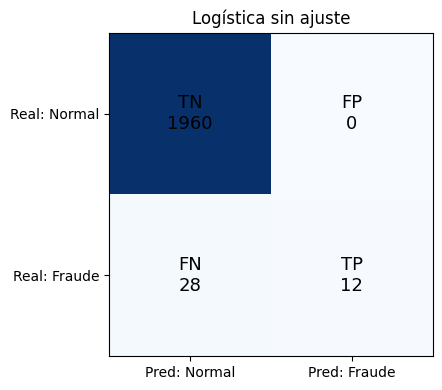

In [5]:
fraudes_reales    = y_test.sum()
fraudes_detectados = ((y_pred == 1) & (y_test == 1)).sum()
print(f'Fraudes detectados: {fraudes_detectados} de {fraudes_reales}')

# La matriz de confusión lo muestra más claro
cm = confusion_matrix(y_test, y_pred)
print(cm)


fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')

etiquetas = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{etiquetas[i][j]}\n{cm[i][j]}', ha='center', va='center', fontsize=13)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: Normal', 'Pred: Fraude'])
ax.set_yticklabels(['Real: Normal', 'Real: Fraude'])
ax.set_title('Logística sin ajuste')
plt.tight_layout()
plt.show()



---
## 2. `class_weight='balanced'`

En lugar de tratar todas las muestras igual, le damos más peso a la clase minoritaria.

sklearn calcula el peso de cada clase así:

$$w_j = \frac{n_{\text{muestras}}}{n_{\text{clases}} \times n_j}$$

Con un dataset 98/2, cada fraude pesa ~49x más que una transacción normal en la función de pérdida.
El modelo aprende que equivocarse en un fraude es mucho más costoso.

> No cambia los datos. Solo cambia cómo se calcula el error durante el entrenamiento.

In [ ]:
# Calculamos los pesos a mano para entender qué hace sklearn
n         = len(y_train)
n_normal  = (y_train == 0).sum()
n_fraude  = (y_train == 1).sum()

w_normal = n / (2 * n_normal)
w_fraude = n / (2 * n_fraude)

print(f'Peso clase Normal (n={n_normal}): {w_normal:.4f}')
print(f'Peso clase Fraude (n={n_fraude}):  {w_fraude:.2f}')
print(f'Un fraude pesa {w_fraude/w_normal:.0f}x más.')

Peso clase Normal (n=7840): 0.5102
Peso clase Fraude (n=160):  25.00
Un fraude pesa 49x más.


In [ ]:
modelo_bal = LogisticRegression(class_weight='balanced', random_state=42)


modelo_bal.fit(X_train, y_train)
y_pred_bal = modelo_bal.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_bal))
print()
print(classification_report(y_test, y_pred_bal, target_names=['Normal', 'Fraude']))

Accuracy: 0.816

              precision    recall  f1-score   support

      Normal       1.00      0.82      0.90      1960
      Fraude       0.09      0.85      0.16        40

    accuracy                           0.82      2000
   macro avg       0.54      0.83      0.53      2000
weighted avg       0.98      0.82      0.88      2000



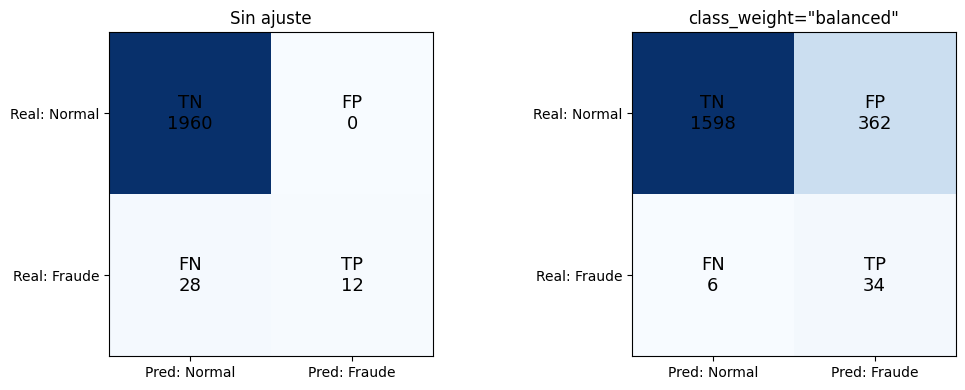

In [ ]:
# Comparamos las dos matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, titulo in zip(axes,
                             [y_pred, y_pred_bal],
                             ['Sin ajuste', 'class_weight="balanced"']):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm, cmap='Blues')
    etiquetas = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{etiquetas[i][j]}\n{cm[i][j]}', ha='center', va='center', fontsize=13)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Normal', 'Pred: Fraude'])
    ax.set_yticklabels(['Real: Normal', 'Real: Fraude'])
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

---
## 3. Sobremuestreo y submuestreo

Otras estrategias que actúan sobre los **datos** directamente:

- **Submuestreo:** eliminar ejemplos de la clase mayoritaria hasta igualar las clases
- **Sobremuestreo:** duplicar (o crear) ejemplos de la clase minoritaria
- **SMOTE:** crear ejemplos sintéticos interpolando entre pares de ejemplos de la clase minoritaria

In [16]:
idx_normal = np.where(y_train == 0)[0]
idx_fraude = np.where(y_train == 1)[0]
n_crear    = len(idx_normal) - len(idx_fraude)
print(n_crear)

idx_sub  = np.random.choice(idx_normal, size=len(idx_fraude), replace=False)
print(idx_sub, idx_fraude.shape)

idx_sub  = np.concatenate([idx_sub, idx_fraude])
X_sub    = X_train[idx_sub]
y_sub    = y_train[idx_sub]

7680
[ 799  811 4152 5674 4795 4744 1255 2813 6628 5655 6571 2826 7940 5909
 6972 4393 1660 6559 3498  608 6119 1794 1022 6808 2460 4949 5439 4730
 4727 1138 1823  844 4334 2497 5426 1662 6833 1777 3879 1651 1203 4645
  282 5382 2397 5735 1243 4757 2712 5727 6707 5773  613 1602 7217 4838
 7818 1899 4102 1724 3422 3493  711 6777 3175 1951 6283 5900 7043 7345
 6648 2138 6015  731 3760 1099 4614 3041 2085 3923 6767 2363 3209  201
 4850 5024  912 2782  318 1018 2674 1057 1676 4773 6961 7851  974 2786
 7213 2581 2553 2793 6739  104 1185 3001 2700 7804 6395 6076  294 1406
 6757   21 4158 4190 1504  797 3060 5064 4457 7199  451 5327 1699 3497
 7385 1969 2530 7693 7600 7425 4888 6366 3927 3079 1112 5045 4946 3168
 1895 7593 1115 3334 6078 4463 7994 1780  531 7896 2598 1288 2381 1845
 1606 1474 5530 6795  493 6008] (160,)


In [20]:
# Submuestreo
idx_sub  = np.random.choice(idx_normal, size=len(idx_fraude), replace=False)
print(idx_sub.shape, idx_fraude.shape)

idx_sub  = np.concatenate([idx_sub, idx_fraude])
X_sub    = X_train[idx_sub]
y_sub    = y_train[idx_sub]

print(X_sub.shape, y_sub.shape)



# Sobremuestreo (duplicar con ruido leve)
idx_dup  = np.random.choice(idx_fraude, size=n_crear, replace=True)
X_over   = np.vstack([X_train, X_train[idx_dup] + np.random.normal(0, 0.01, X_train[idx_dup].shape)])
y_over   = np.concatenate([y_train, np.ones(n_crear, dtype=int)])



# SMOTE manual: interpolación entre pares de fraudes
X_fr     = X_train[idx_fraude]
i1, i2   = np.random.randint(0, len(X_fr), n_crear), np.random.randint(0, len(X_fr), n_crear)
print(i1,i2)
alpha    = np.random.rand(n_crear, 1)
print(alpha)

sint     = X_fr[i1] * alpha + X_fr[i2] * (1 - alpha)
X_smote  = np.vstack([X_train, sint])
y_smote  = np.concatenate([y_train, np.ones(n_crear, dtype=int)])

print('Submuestreo:  ', pd.Series(y_sub).value_counts().to_dict())
print('Sobremuestreo:', pd.Series(y_over).value_counts().to_dict())
print('SMOTE:        ', pd.Series(y_smote).value_counts().to_dict())

(160,) (160,)
(320, 10) (320,)
[ 68 133 131 ...  83 133  44] [125 147  92 ...  81  11 120]
[[0.44984588]
 [0.03707255]
 [0.90817291]
 ...
 [0.08751067]
 [0.16435105]
 [0.66954403]]
Submuestreo:   {0: 160, 1: 160}
Sobremuestreo: {0: 7840, 1: 7840}
SMOTE:         {0: 7840, 1: 7840}


In [22]:
# Entrenamos un modelo con cada estrategia y comparamos
estrategias = {
    'Sin ajuste':    (X_train, y_train, {}),
    'class_weight':  (X_train, y_train, {'class_weight': 'balanced'}),
    'Submuestreo':   (X_sub,   y_sub,   {}),
    'Sobremuestreo': (X_over,  y_over,  {}),
    'SMOTE':         (X_smote, y_smote, {}),
}

modelos = {}
filas   = []

for nombre, (Xtr, ytr, kwargs) in estrategias.items():
    m = LogisticRegression(random_state=42, max_iter=1000, **kwargs)
    m.fit(Xtr, ytr)
    modelos[nombre] = m
    yp = m.predict(X_test)
    filas.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, yp), 3),
        'Precision': round(precision_score(y_test, yp, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, yp), 3),
        'F1':        round(f1_score(y_test, yp), 3),
    })

print(pd.DataFrame(filas).set_index('Modelo').to_string())

               Accuracy  Precision  Recall     F1
Modelo                                           
Sin ajuste        0.986      1.000    0.30  0.462
class_weight      0.816      0.086    0.85  0.156
Submuestreo       0.820      0.087    0.85  0.159
Sobremuestreo     0.816      0.086    0.85  0.156
SMOTE             0.834      0.094    0.85  0.170


---
## 4. Umbral de decisión

La regresión logística devuelve una probabilidad. Por defecto predice fraude si `P >= 0.5`.

Podemos cambiar ese umbral:
- Umbral bajo → detectamos más fraudes → Recall sube, Precision baja
- Umbral alto → solo alertamos cuando estamos muy seguros → Precision sube, Recall baja

En fraude bancario nos interesa Recall alto: es peor dejar pasar un fraude que generar una falsa alarma.

In [27]:
modelos["SMOTE"].predict_proba(X_test)


array([[0.40521686, 0.59478314],
       [0.38585328, 0.61414672],
       [0.14379576, 0.85620424],
       ...,
       [0.45138031, 0.54861969],
       [0.88066209, 0.11933791],
       [0.96107725, 0.03892275]], shape=(2000, 2))

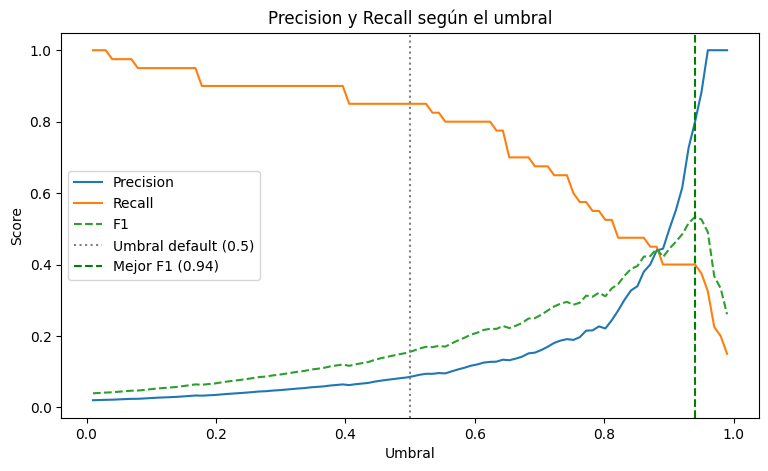

In [28]:
y_proba = modelos['class_weight'].predict_proba(X_test)[:, 1]

umbrales    = np.linspace(0.01, 0.99, 100)
precisiones = [precision_score(y_test, (y_proba >= u).astype(int), zero_division=0) for u in umbrales]
recalls     = [recall_score(y_test,    (y_proba >= u).astype(int)) for u in umbrales]
f1s         = [f1_score(y_test,        (y_proba >= u).astype(int)) for u in umbrales]

mejor_umbral = umbrales[np.argmax(f1s)]

plt.figure(figsize=(9, 5))
plt.plot(umbrales, precisiones, label='Precision')
plt.plot(umbrales, recalls,     label='Recall')
plt.plot(umbrales, f1s,         label='F1', linestyle='--')
plt.axvline(0.5,          color='gray', linestyle=':', label='Umbral default (0.5)')
plt.axvline(mejor_umbral, color='green', linestyle='--', label=f'Mejor F1 ({mejor_umbral:.2f})')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Precision y Recall según el umbral')
plt.legend()
plt.show()

In [36]:
# Evaluamos el modelo con el mejor umbral
y_pred_mejor = (y_proba >= 0.78).astype(int)    

print(classification_report(y_test, y_pred_mejor, target_names=['Normal', 'Fraude']))

              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97      1960
      Fraude       0.22      0.55      0.31        40

    accuracy                           0.95      2000
   macro avg       0.60      0.75      0.64      2000
weighted avg       0.98      0.95      0.96      2000



---
## 5. Curva Precision-Recall - ¿cuando el modelo grita "fraude", cuántas veces tiene razón?

En vez de evaluar un umbral fijo, la curva PR muestra el trade-off completo a todos los umbrales.

El área bajo la curva (AP) resume la calidad del modelo en un número.
Un clasificador aleatorio con 2% de fraudes tiene AP ≈ 0.02.

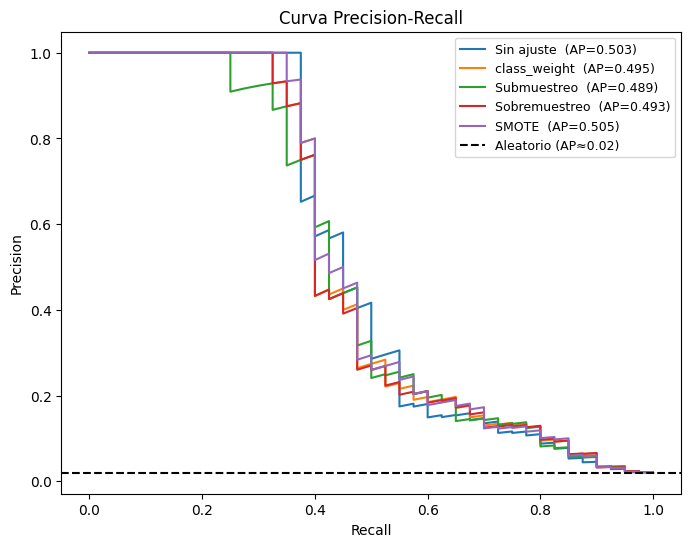

In [14]:
plt.figure(figsize=(8, 6))

for nombre, modelo in modelos.items():
    proba        = modelo.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap           = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f'{nombre}  (AP={ap:.3f})')

plt.axhline(y_test.mean(), color='black', linestyle='--', label=f'Aleatorio (AP≈{y_test.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(fontsize=9)
plt.show()

---
## 6. Curva ROC y AUC-ROC - ¿El modelo sabe distinguir un fraude de una transacción normal?

La curva ROC muestra el trade-off entre:
- **TPR** (Recall): TP / (TP + FN) — cuántos fraudes detectamos
- **FPR**: FP / (FP + TN) — cuántas falsas alarmas generamos

AUC = 0.5 → aleatorio. AUC = 1.0 → perfecto.

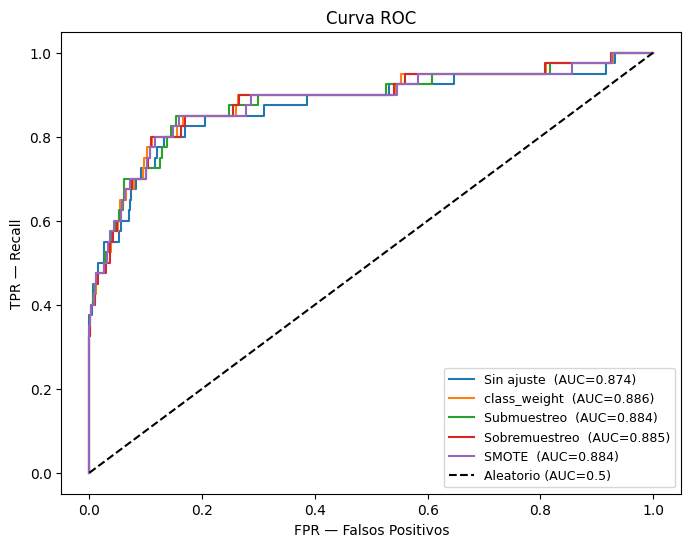

In [37]:
plt.figure(figsize=(8, 6))

for nombre, modelo in modelos.items():
    proba        = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nombre}  (AUC={auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.5)')
plt.xlabel('FPR — Falsos Positivos')
plt.ylabel('TPR — Recall')
plt.title('Curva ROC')
plt.legend(fontsize=9)
plt.show()

---
## 7. ¿Cuándo usar PR vs ROC?

Este es el punto más importante. Veamos por qué ROC puede engañar en datasets desbalanceados.

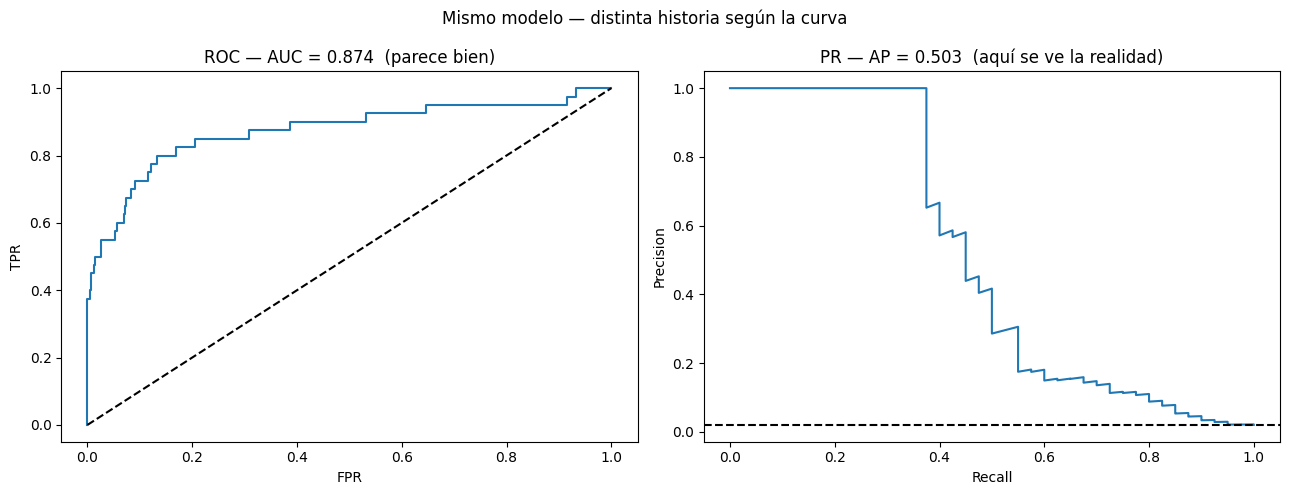

In [16]:
# El modelo "Sin ajuste" tiene buen AUC-ROC pero mal AP
# Veamos ambas curvas lado a lado

proba = modelos['Sin ajuste'].predict_proba(X_test)[:, 1]

fpr, tpr, _  = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr)
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title(f'ROC — AUC = {auc(fpr, tpr):.3f}  (parece bien)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

axes[1].plot(rec, prec)
axes[1].axhline(y_test.mean(), color='k', linestyle='--')
axes[1].set_title(f'PR — AP = {average_precision_score(y_test, proba):.3f}  (aquí se ve la realidad)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')

plt.suptitle('Mismo modelo — distinta historia según la curva')
plt.tight_layout()
plt.show()

### ¿Por qué pasa esto?

Con un dataset muy desbalanceado hay **muchísimos negativos**. El FPR divide por todos ellos, entonces aunque el modelo genere muchos falsos positivos, el FPR se ve pequeño.

La curva PR en cambio trabaja directamente con los positivos, entonces el desbalanceo queda expuesto.

---

### Regla simple

| Situación | Métrica recomendada |
|---|---|
| Dataset balanceado | ROC / AUC |
| Clase positiva rara (fraude, enfermedad, falla) | Curva PR / AP |

### Resumen de estrategias

| Estrategia | Cambia los datos | Cuándo usarla |
|---|---|---|
| `class_weight='balanced'` | No | Siempre es buen punto de partida |
| Submuestreo | Sí (pierde datos) | Dataset muy grande |
| Sobremuestreo | Sí | Dataset pequeño |
| SMOTE | Sí (datos sintéticos) | Quieres más diversidad que duplicar |
| Ajustar umbral | No | Cuando el negocio define el trade-off |